In [1]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from IPython import display

import matplotlib.pyplot as plt
%matplotlib inline

import time
from tqdm.auto import tqdm

torch version: 2.7.1+cu118
torchvision version: 0.22.1+cu118
Using device: cuda


In [2]:
# This function will plot five images from an array

In [3]:
def plot_array(X, title=""):
    """
    Plot the first 5 images from a batch tensor.

    Expects X to be a PyTorch tensor of shape (N, C, H, W) — the standard
    PyTorch channel-first format.  We permute to (H, W, C) before handing
    off to matplotlib.
    """
    plt.rcParams['figure.figsize'] = (20, 20)

    for i, x in enumerate(X[0:5]):
        # x has shape (C, H, W); permute to (H, W, C) for matplotlib
        x = x.permute(1, 2, 0).cpu().numpy()
        max_ = x.max()
        min_ = x.min()
        xnew = np.uint8(255 * (x - min_) / (max_ - min_ + 1e-8))
        plt.subplot(1, 5, i + 1)
        plt.imshow(xnew)
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

In [4]:
# Loading the dataset

In [5]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

dataset_root = r"D:\Anime_Avatar_DCGAN\cartoon_20000\cartoon_20000"

In [6]:
img_height, img_width, batch_size = 64, 64, 128

In [7]:
# torchvision.datasets.ImageFolder requires subdirectories inside the root folder.
# cartoon_20000 may store images flat (no class subfolders).
# We handle both layouts: if images are already in a subfolder use the root directly,
# otherwise wrap them in a single dummy subfolder on-the-fly using a symlink
import shutil

dataset_root = "cartoon_20000"

# Check whether the directory already contains subdirectories (ImageFolder layout)
entries = os.listdir(dataset_root)
has_subdirs = any(os.path.isdir(os.path.join(dataset_root, e)) for e in entries)

if not has_subdirs:
    # Wrap flat images in a dummy class subfolder expected by ImageFolder
    wrapped_root = "cartoon_20000_wrapped"
    class_dir = os.path.join(wrapped_root, "images")
    os.makedirs(class_dir, exist_ok=True)
    for fname in entries:
        src = os.path.abspath(os.path.join(dataset_root, fname))
        dst = os.path.join(class_dir, fname)
        if not os.path.exists(dst):
            os.symlink(src, dst)
    dataset_root = wrapped_root

# Define the transform pipeline:
#   Resize  → CenterCrop → ToTensor (scales to [0,1]) → Normalize to [-1,1]
transform = transforms.Compose([
    transforms.Resize(img_height),
    transforms.CenterCrop((img_height, img_width)),
    transforms.ToTensor(),                                    # (C, H, W) in [0, 1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # rescale to [-1, 1]
])

# ImageFolder assigns dummy integer labels; we simply ignore them during training
dataset = datasets.ImageFolder(root=dataset_root, transform=transform)

train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    drop_last=True        # keeps every batch exactly batch_size images
)

print(f"Total images : {len(dataset)}")
print(f"Total batches: {len(train_loader)}")

Total images : 20000
Total batches: 156


In [8]:
sample_iter = iter(train_loader)
images_batch, _ = next(sample_iter)   # shape: (batch_size, 3, 64, 64)

In [9]:
# X[0] gives the full batch tensor, identical indexing to the original notebook
X = [images_batch]   # X[0] → shape: (batch_size, 3, 64, 64)

In [10]:
# This cell is kept as a placeholder to preserve notebook structure.
normalized_loader = train_loader  # alias used in the training loop

In [11]:
# Grab a single batch from the DataLoader.
# DataLoader yields (images, labels); we only need the images.
sample_iter = iter(train_loader)
sample_images, _ = next(sample_iter)   # shape: (batch_size, 3, 64, 64)

In [12]:
# Here each element of X is one batch tensor of shape (batch_size, C, H, W).
X = [sample_images]

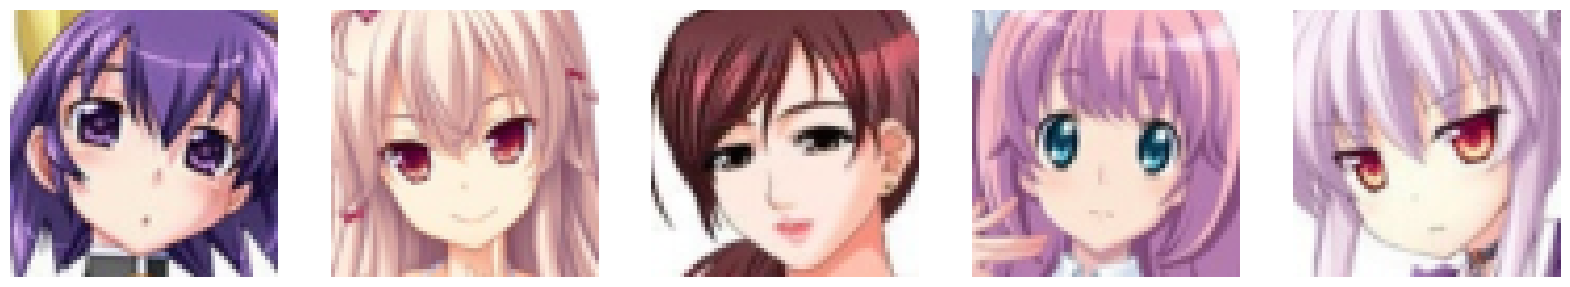

In [13]:
plot_array(X[0])

In [14]:
# Building generator and discriminator

In [15]:
def make_generator():
    """
    Building the DCGAN Generator as a PyTorch nn.Sequential model.

    Input  : latent noise vector of shape (N, 100, 1, 1) ( PyTorch NCHW format).
    Output : generated image of shape   (N,   3, 64, 64) normalized to [-1, 1].
     
      Input  (N,100,1,1)
      ConvTranspose2d → (N,512,4,4)   stride=4, no bias, BN, ReLU
      ConvTranspose2d → (N,256,8,8)   stride=2, no bias, BN, ReLU
      ConvTranspose2d → (N,128,16,16) stride=2, no bias, BN, ReLU
      ConvTranspose2d → (N, 64,32,32) stride=2, no bias, BN, ReLU
      ConvTranspose2d → (N,  3,64,64) stride=2, no bias, Tanh
    """
    # Weight initialiser: Normal(mean=0, std=0.02) — same as Keras RandomNormal
    def _weights_init(m):
        if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
            nn.init.normal_(m.weight.data, mean=0.0, std=0.02)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, mean=1.0, std=0.02)
            nn.init.constant_(m.bias.data, 0)

    model = nn.Sequential(
        # Block 1: (N, 100, 1, 1) → (N, 512, 4, 4)
        # stride=4 with kernel=4 and padding=0 gives output size = (1-1)*4 + 4 = 4
        nn.ConvTranspose2d(100, 64 * 8, kernel_size=4, stride=4, padding=0, bias=False),
        nn.BatchNorm2d(64 * 8, momentum=0.1, eps=0.8),
        nn.ReLU(inplace=True),

        # Block 2: (N, 512, 4, 4) → (N, 256, 8, 8)
        nn.ConvTranspose2d(64 * 8, 64 * 4, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(64 * 4, momentum=0.1, eps=0.8),
        nn.ReLU(inplace=True),

        # Block 3: (N, 256, 8, 8) → (N, 128, 16, 16)
        nn.ConvTranspose2d(64 * 4, 64 * 2, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(64 * 2, momentum=0.1, eps=0.8),
        nn.ReLU(inplace=True),

        # Block 4: (N, 128, 16, 16) → (N, 64, 32, 32)
        nn.ConvTranspose2d(64 * 2, 64 * 1, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(64 * 1, momentum=0.1, eps=0.8),
        nn.ReLU(inplace=True),

        # Block 5 (output): (N, 64, 32, 32) → (N, 3, 64, 64)
        nn.ConvTranspose2d(64 * 1, 3, kernel_size=4, stride=2, padding=1, bias=False),
        nn.Tanh()
    )

    model.apply(_weights_init)
    return model

In [16]:
gen = make_generator()
print(gen)

# Count trainable parameters
total_params = sum(p.numel() for p in gen.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

Sequential(
  (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(4, 4), bias=False)
  (1): BatchNorm2d(512, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (4): BatchNorm2d(256, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (7): BatchNorm2d(128, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU(inplace=True)
  (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (10): BatchNorm2d(64, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU(inplace=True)
  (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (13): Tanh()
)

Total trainable parameters: 3,576,704


In [17]:
def make_discriminator():
    """
    Building the DCGAN Discriminator as a PyTorch nn.Sequential model.

    Input  : real or fake image of shape (N,  3, 64, 64) in [-1, 1].
    Output : scalar probability per image of shape (N, 1,  1,  1).

      Input  (N,  3, 64, 64)
      Conv2d → (N,  64, 32, 32)  stride=2, no BN,  LeakyReLU(0.2)
      Conv2d → (N, 128, 16, 16)  stride=2, BN,     LeakyReLU(0.2)
      Conv2d → (N, 256,  8,  8)  stride=2, BN,     LeakyReLU(0.2)
      Conv2d → (N, 512,  4,  4)  stride=2, BN,     LeakyReLU(0.2)
      Conv2d → (N,   1,  1,  1)  stride=2, no BN,  Sigmoid

    Note: We use nn.BCELoss (not BCEWithLogitsLoss) because the final layer
    applies Sigmoid explicitly — matching the original Keras model exactly.
    """
    def _weights_init(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, mean=0.0, std=0.02)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, mean=1.0, std=0.02)
            nn.init.constant_(m.bias.data, 0)

    model = nn.Sequential(
        # Block 1: (N, 3, 64, 64) → (N, 64, 32, 32)  — no BN on first layer
        nn.Conv2d(3,      64,     kernel_size=4, stride=2, padding=1, bias=False),
        nn.LeakyReLU(0.2, inplace=True),

        # Block 2: (N, 64, 32, 32) → (N, 128, 16, 16)
        nn.Conv2d(64,     64 * 2, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(64 * 2, momentum=0.1, eps=0.8),
        nn.LeakyReLU(0.2, inplace=True),

        # Block 3: (N, 128, 16, 16) → (N, 256, 8, 8)
        nn.Conv2d(64 * 2, 64 * 4, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(64 * 4, momentum=0.1, eps=0.8),
        nn.LeakyReLU(0.2, inplace=True),

        # Block 4: (N, 256, 8, 8) → (N, 512, 4, 4)
        nn.Conv2d(64 * 4, 64 * 8, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(64 * 8, momentum=0.1, eps=0.8),
        nn.LeakyReLU(0.2, inplace=True),

        # Block 5 (output): (N, 512, 4, 4) → (N, 1, 1, 1)  — Sigmoid, no BN
        nn.Conv2d(64 * 8, 1,      kernel_size=4, stride=2, padding=1, bias=False),
        nn.Sigmoid()
    )

    model.apply(_weights_init)
    return model

In [18]:
disc = make_discriminator()
print(disc)

total_params = sum(p.numel() for p in disc.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

Sequential(
  (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (1): LeakyReLU(negative_slope=0.2, inplace=True)
  (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (3): BatchNorm2d(128, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.2, inplace=True)
  (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (6): BatchNorm2d(256, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (7): LeakyReLU(negative_slope=0.2, inplace=True)
  (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (9): BatchNorm2d(512, eps=0.8, momentum=0.1, affine=True, track_running_stats=True)
  (10): LeakyReLU(negative_slope=0.2, inplace=True)
  (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (12): Sigmoid()
)

Total trainable parameters: 2,765,568


In [19]:
# Defining the Loss Functions

In [20]:
# Binary Cross Entropy loss — expects sigmoid-activated outputs (probabilities)
criterion = nn.BCELoss()

In [21]:
def generator_loss(fake_output):
    """
    Generator wants the discriminator to classify fake images as real (label=1).
    """
    real_labels = torch.ones_like(fake_output, device=fake_output.device)
    return criterion(fake_output, real_labels)

In [22]:
def discriminator_loss(real_output, fake_output):
    """
    Discriminator wants to correctly classify real images (label=1) and fake images (label=0).
    """
    real_labels = torch.ones_like(real_output, device=real_output.device)
    fake_labels = torch.zeros_like(fake_output, device=fake_output.device)
    real_loss = criterion(real_output, real_labels)
    fake_loss = criterion(fake_output, fake_labels)
    total_loss = 0.5 * (real_loss + fake_loss)
    return total_loss

In [23]:
#Defining the Optimizers

In [24]:
learning_rate = 0.0002

# Instantiate models and move them to the target device (GPU if available, else CPU)
generator     = make_generator().to(device)
discriminator = make_discriminator().to(device)

generator_optimizer     = torch.optim.Adam(generator.parameters(),
                                           lr=learning_rate, betas=(0.5, 0.999))
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(),
                                           lr=learning_rate, betas=(0.5, 0.999))

In [25]:
# Creating the train step function

In [26]:
def train_step(X):
    """
    Perform one training step for both Generator and Discriminator.

    Args:
        X: A batch of real images, shape (N, 3, H, W), already on `device`.

    Returns:
        gen_loss_val  (float): Generator loss for this step.
        disc_loss_val (float): Discriminator loss for this step.
    """
    BATCH_SIZE = X.size(0)

    # 1) Sample latent noise: shape (N, latent_dim, 1, 1)
    z = torch.randn(BATCH_SIZE, latent_dim, 1, 1, device=device)

    # 2) Train Discriminator                                               
    discriminator.zero_grad()

    # Forward pass: real images
    real_output = discriminator(X)     # shape: (N, 1, 1, 1)

    # Forward pass: generated (fake) images — detach so gradients don't flow into the generator during the discriminator update
    xhat = generator(z)                        # shape: (N, 3, H, W)
    fake_output = discriminator(xhat.detach()) # detach from generator graph

    disc_loss = discriminator_loss(real_output, fake_output)
    disc_loss.backward()                       # compute gradients
    discriminator_optimizer.step()             # update discriminator weights

    # 3) Train Generator                                                   
    generator.zero_grad()

    # Re-run discriminator on the same fake batch (without detach this time so gradients flow back to the generator)
    fake_output_for_gen = discriminator(xhat)

    gen_loss = generator_loss(fake_output_for_gen)
    gen_loss.backward()                        # compute gradients
    generator_optimizer.step()                 # update generator weights

    return gen_loss.item(), disc_loss.item()

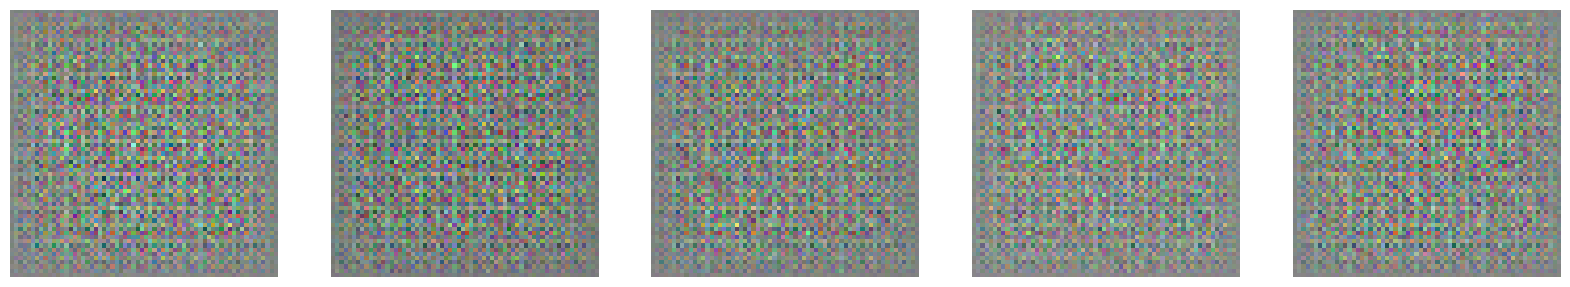

In [27]:
generator  = make_generator().to(device)
BATCH_SIZE = 128
latent_dim = 100

# Noise shape in PyTorch: (N, latent_dim, 1, 1)
noise = torch.randn(BATCH_SIZE, latent_dim, 1, 1, device=device)

generator.eval()
with torch.no_grad():
    Xhat = generator(noise)   # shape: (N, 3, 64, 64)

plot_array(Xhat)

In [28]:
#Training the model

epoch 1:   0%|          | 0/156 [00:06<?, ?it/s]

original images


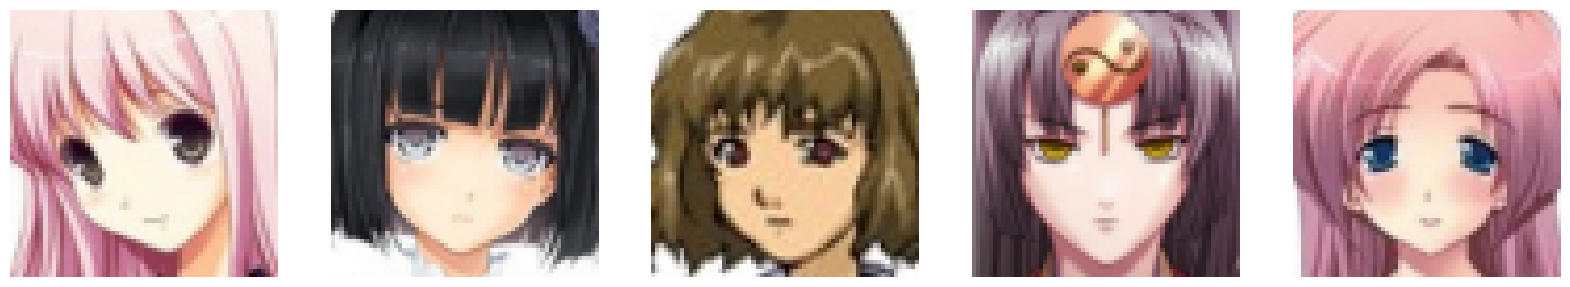

generated images


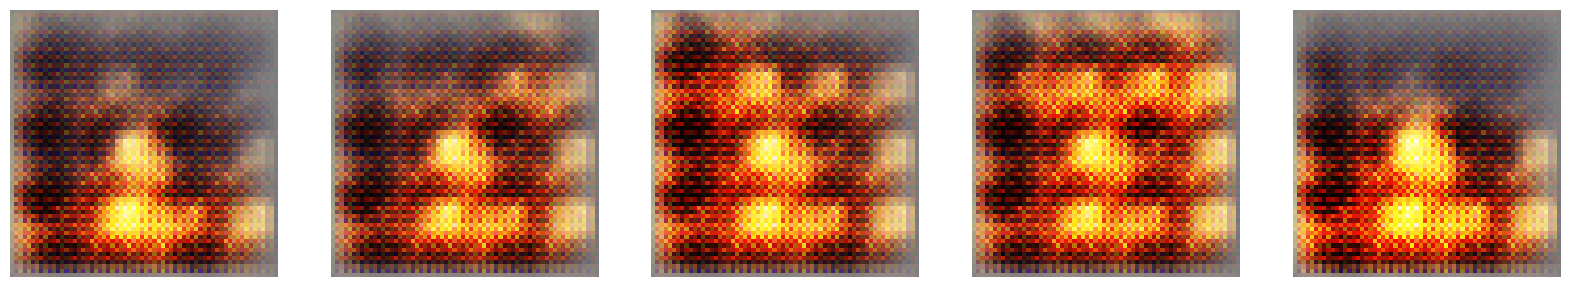

Time for epoch 1 is 45.19 sec


In [29]:
epochs = 1

# (Re-)initialize fresh models and move to device
discriminator = make_discriminator().to(device)
generator     = make_generator().to(device)

# Re-initialize optimizers to match the fresh models
generator_optimizer     = torch.optim.Adam(generator.parameters(),
                                           lr=learning_rate, betas=(0.5, 0.999))
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(),
                                           lr=learning_rate, betas=(0.5, 0.999))

for epoch in range(epochs):

    start = time.time()
    i = 0

    # Set both models to training mode (enables BatchNorm and Dropout behaviour)
    generator.train()
    discriminator.train()

    for X, _ in tqdm(normalized_loader, desc=f"epoch {epoch+1}", total=len(normalized_loader)):

        # Move the real image batch to the target device
        X = X.to(device)   # shape: (N, 3, 64, 64)
        i += 1

        g_loss, d_loss = train_step(X)

        if i % 1000 == 0:
            print(f"epoch {epoch+1}, iteration {i}  |  g_loss: {g_loss:.4f}  d_loss: {d_loss:.4f}")

    # End-of-epoch visualisation
    noise = torch.randn(BATCH_SIZE, latent_dim, 1, 1, device=device)

    generator.eval()
    with torch.no_grad():
        Xhat = generator(noise)   # shape: (N, 3, 64, 64)

    # Show a batch of real images
    real_batch, _ = next(iter(normalized_loader))
    print("original images")
    plot_array(real_batch)

    print("generated images")
    plot_array(Xhat)

    print(f"Time for epoch {epoch+1} is {time.time() - start:.2f} sec")

In [30]:
# Loading pre-trained weights from an extended training run for improved fidelity.
# Training configuration: ~65k image dataset, batch_size=128, epochs=150 (500 iterations/epoch).

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

full_generator = make_generator().to(device)
full_generator.load_state_dict(
    torch.load(r"D:\Anime_Avatar_DCGAN\generator_pytorch.pt", map_location=device)
)
full_generator.eval()

# Sanity check
with torch.no_grad():
    test_out = full_generator(torch.randn(4, 100, 1, 1, device=device))

print(f"✅ Pre-trained generator loaded successfully!")
print(f"   Output shape : {test_out.shape}")
print(f"   Output range : [{test_out.min():.3f}, {test_out.max():.3f}]")

✅ Pre-trained generator loaded successfully!
   Output shape : torch.Size([4, 3, 64, 64])
   Output range : [-0.964, 1.000]


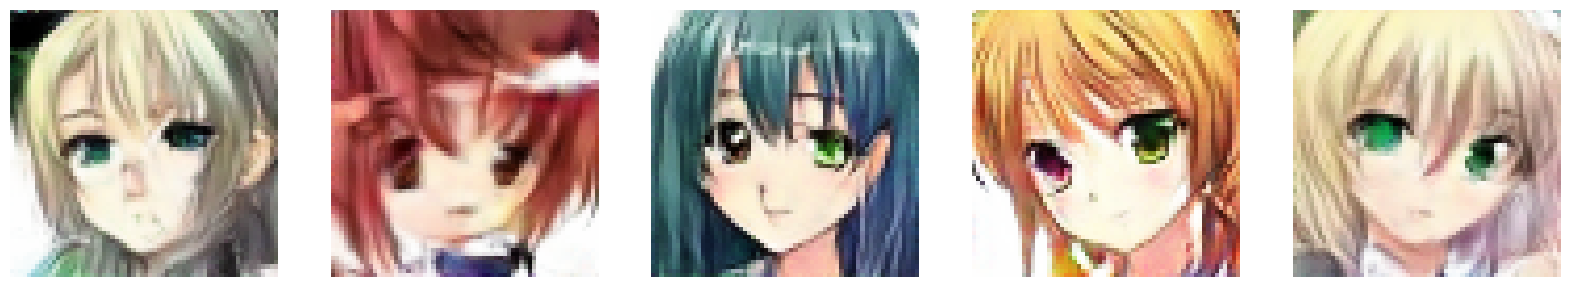

In [32]:
latent_dim = 100

# Input noise: (N, latent_dim, 1, 1)
noise = torch.randn(200, latent_dim, 1, 1, device=device)

full_generator.eval()
with torch.no_grad():
    Xhat = full_generator(noise)   # shape: (200, 3, 64, 64)

plot_array(Xhat)

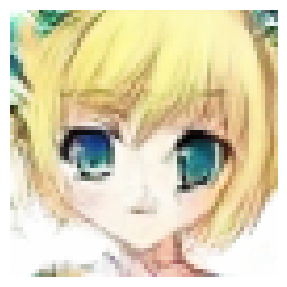

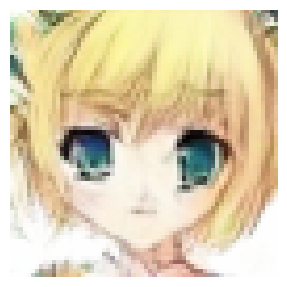

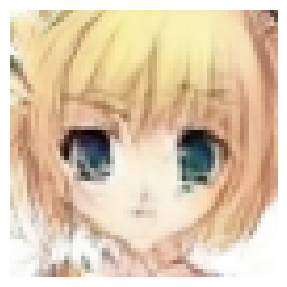

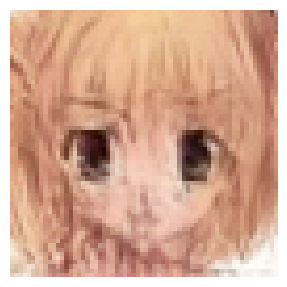

In [33]:
for c in [1, 0.8, 0.6, 0.4]:
    # PyTorch latent shape is (N, latent_dim, 1, 1)
    z = c * torch.ones(1, latent_dim, 1, 1, device=device)

    full_generator.eval()
    with torch.no_grad():
        Xhat = full_generator(z)   # shape: (1, 3, 64, 64)

    plot_array(Xhat)

z filled with value: -1.0


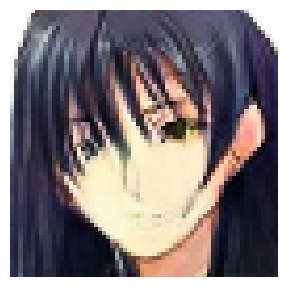

z filled with value: -0.8


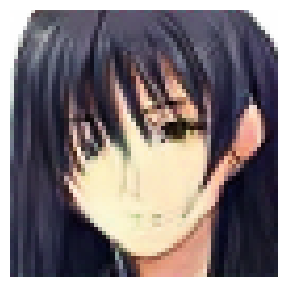

z filled with value: -0.6


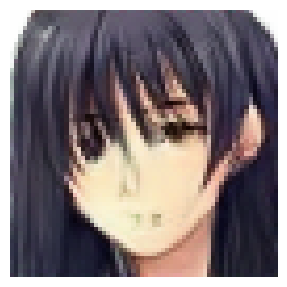

z filled with value: -0.4


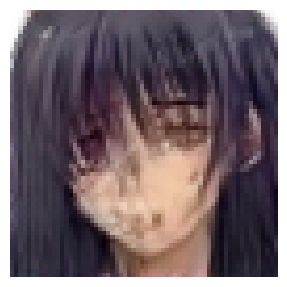

In [34]:
for c in [1, 0.8, 0.6, 0.4]:
    # Fill the entire latent vector with -c (negative values)
    z = -c * torch.ones(1, latent_dim, 1, 1, device=device)

    full_generator.eval()
    with torch.no_grad():
        Xhat = full_generator(z)   # shape: (1, 3, 64, 64)

    print(f"z filled with value: {-c:.1f}")
    plot_array(Xhat)

elements from 0 to 0 is set to -1


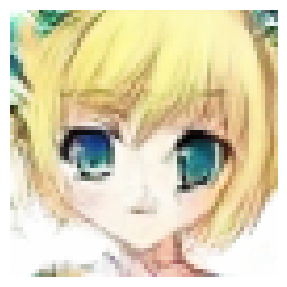

elements from 0 to 10 is set to -1


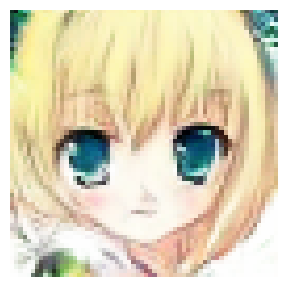

elements from 0 to 20 is set to -1


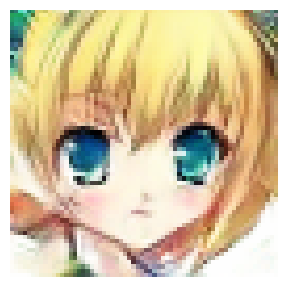

elements from 0 to 30 is set to -1


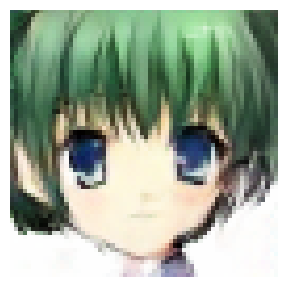

elements from 0 to 40 is set to -1


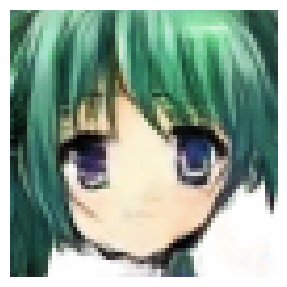

elements from 0 to 50 is set to -1


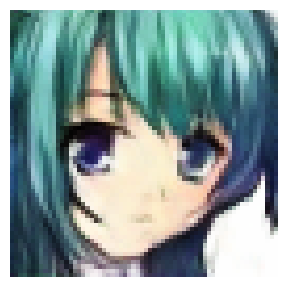

elements from 0 to 60 is set to -1


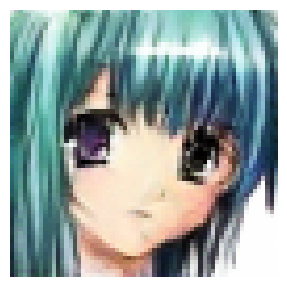

elements from 0 to 70 is set to -1


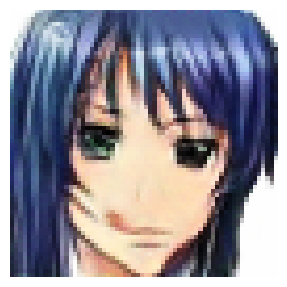

elements from 0 to 80 is set to -1


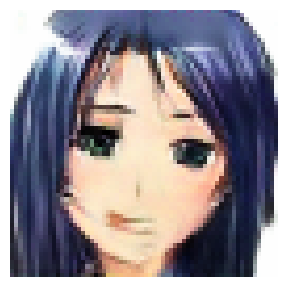

elements from 0 to 90 is set to -1


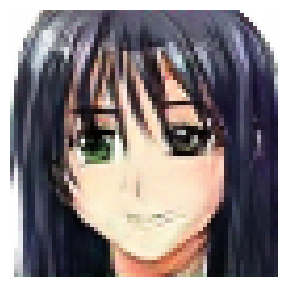

In [35]:
# PyTorch layout is NCHW, so latent vector is (1, latent_dim, 1, 1).
z = np.ones((1, latent_dim, 1, 1))

for n in range(10):
    z[0, 0:10*n, 0, 0] = -1   # set first 10*n channels to -1

    z_tensor = torch.tensor(z, dtype=torch.float32, device=device)

    full_generator.eval()
    with torch.no_grad():
        Xhat = full_generator(z_tensor)

    print(f"elements from 0 to {10*n} is set to -1")
    plot_array(Xhat)

n=0 | first 0 latent dims set to -0.0, rest remain 1.0


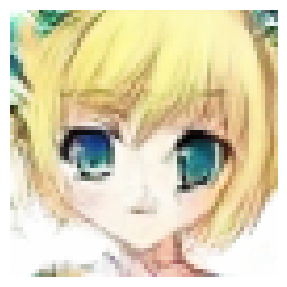

n=1 | first 20 latent dims set to -0.5, rest remain 1.0


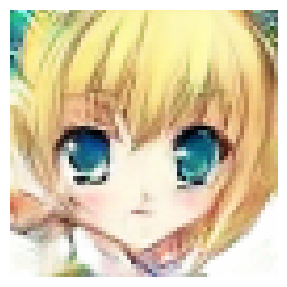

n=2 | first 40 latent dims set to -1.0, rest remain 1.0


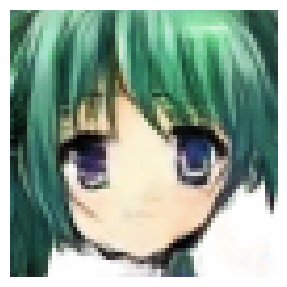

n=3 | first 60 latent dims set to -1.5, rest remain 1.0


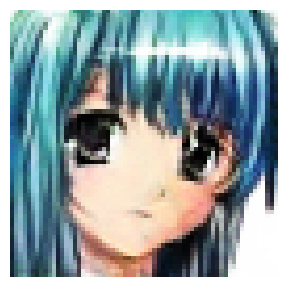

n=4 | first 80 latent dims set to -2.0, rest remain 1.0


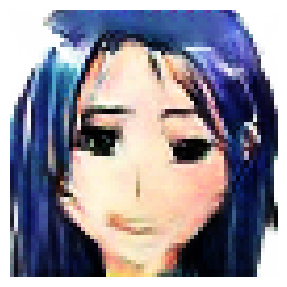

In [36]:
# Start with a latent vector of all ones, shape (1, latent_dim, 1, 1)
z = np.ones((1, latent_dim, 1, 1))

for n in range(5):
    z[0, 0:20*n, 0, 0] = -0.5 * n

    z_tensor = torch.tensor(z, dtype=torch.float32, device=device)

    full_generator.eval()
    with torch.no_grad():
        Xhat = full_generator(z_tensor)   # shape: (1, 3, 64, 64)

    print(f"n={n} | first {20*n} latent dims set to {-0.5*n:.1f}, rest remain 1.0")
    plot_array(Xhat)

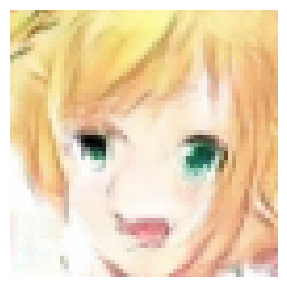

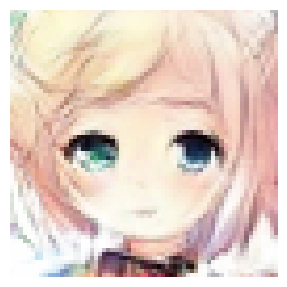

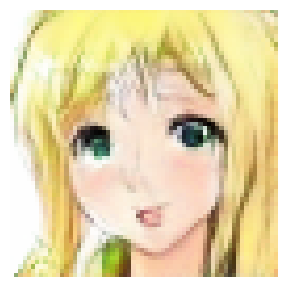

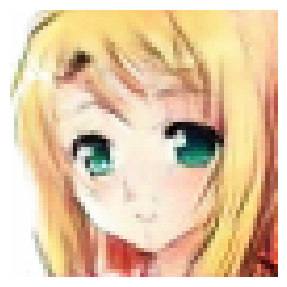

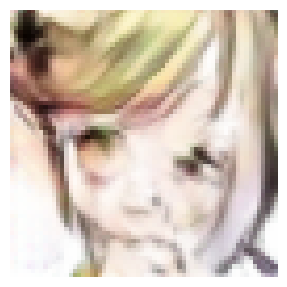

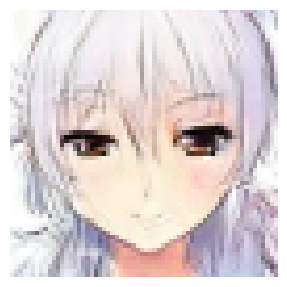

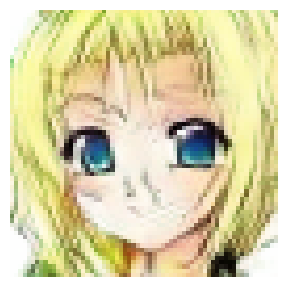

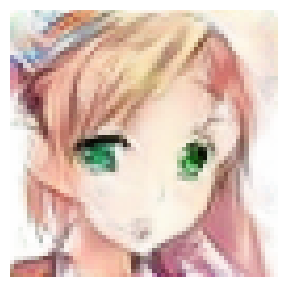

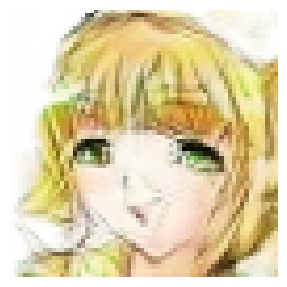

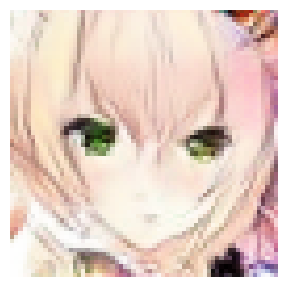

In [37]:
for n in range(10):
    z = np.random.normal(0, 1, (1, latent_dim, 1, 1))

    z[0, 0:35, 0, 0] = 1 

    z_tensor = torch.tensor(z, dtype=torch.float32, device=device)

    full_generator.eval()
    with torch.no_grad():
        Xhat = full_generator(z_tensor)

    plot_array(Xhat)

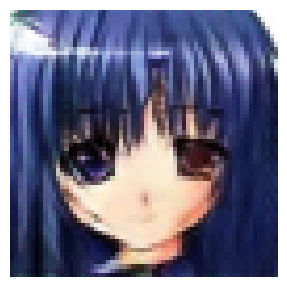

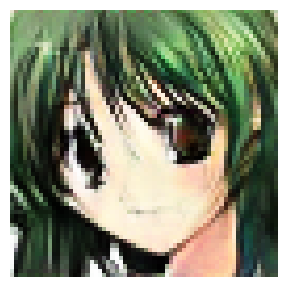

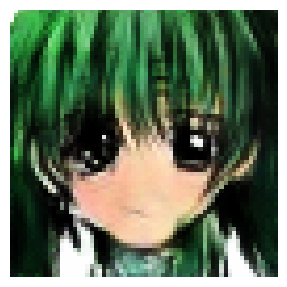

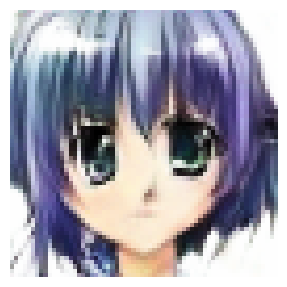

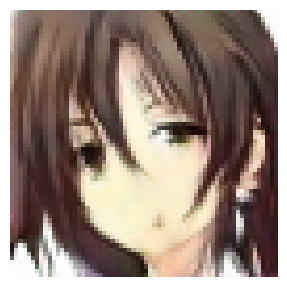

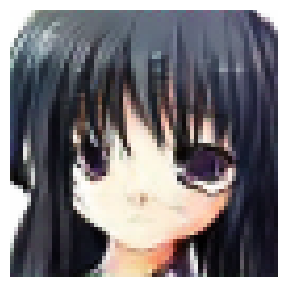

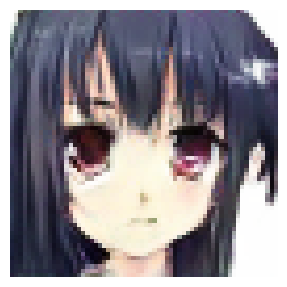

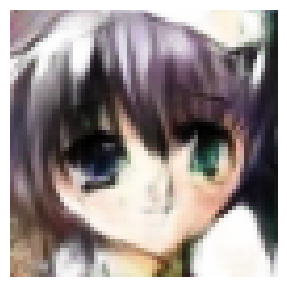

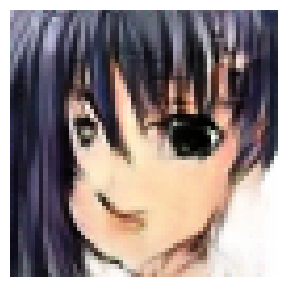

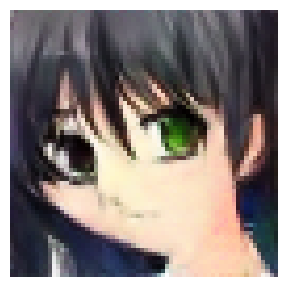

In [38]:
for n in range(10):
    z = np.random.normal(0, 1, (1, latent_dim, 1, 1))

    z[0, 0:35, 0, 0] = -1

    z_tensor = torch.tensor(z, dtype=torch.float32, device=device)

    full_generator.eval()
    with torch.no_grad():
        Xhat = full_generator(z_tensor)

    plot_array(Xhat)